<a href="https://colab.research.google.com/github/siddartha-hub/AI-in-Hanced/blob/main/isro_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SearchResult containing 220 data products.

 #     mission     year       author      exptime target_name distance
                                             s                 arcsec 
--- -------------- ---- ----------------- ------- ----------- --------
  0 TESS Sector 01 2018              SPOC     120    25155310      0.0
  1 TESS Sector 02 2018              SPOC     120    25155310      0.0
  2 TESS Sector 03 2018              SPOC     120    25155310      0.0
  3 TESS Sector 04 2018              SPOC     120    25155310      0.0
  4 TESS Sector 05 2018              SPOC     120    25155310      0.0
  5 TESS Sector 06 2018              SPOC     120    25155310      0.0
  6 TESS Sector 07 2019              SPOC     120    25155310      0.0
  7 TESS Sector 08 2019              SPOC     120    25155310      0.0
  8 TESS Sector 09 2019              SPOC     120    25155310      0.0
  9 TESS Sector 10 2019              SPOC     120    25155310      0.0
 10 TESS Sector 11 2019          

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

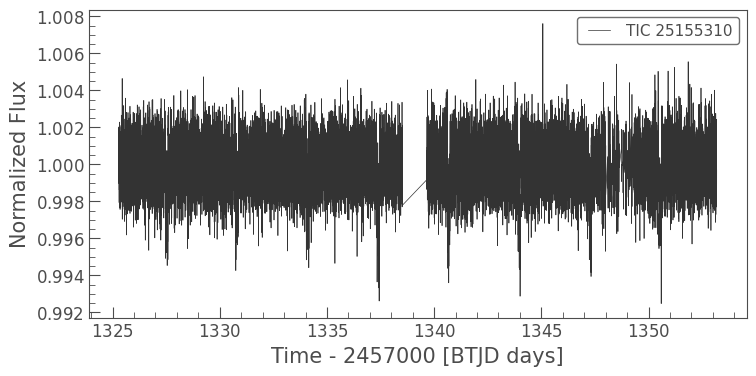

In [24]:
!pip install lightkurve

import lightkurve as lk
search_result = lk.search_lightcurve("TIC25155310", mission="TESS")
print(search_result)
lc = search_result[0].download()
lc_clean = lc.remove_nans().flatten()
lc_clean.plot()

Best Period= 3.319129000863871 d


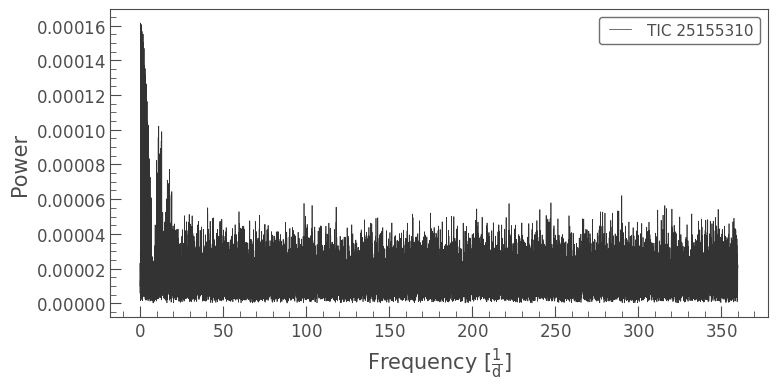

In [25]:
pg=lc_clean.to_periodogram()
pg.plot()

period=pg.period_at_max_power
print("Best Period=",period)

<Axes: xlabel='Phase [JD]', ylabel='Normalized Flux'>

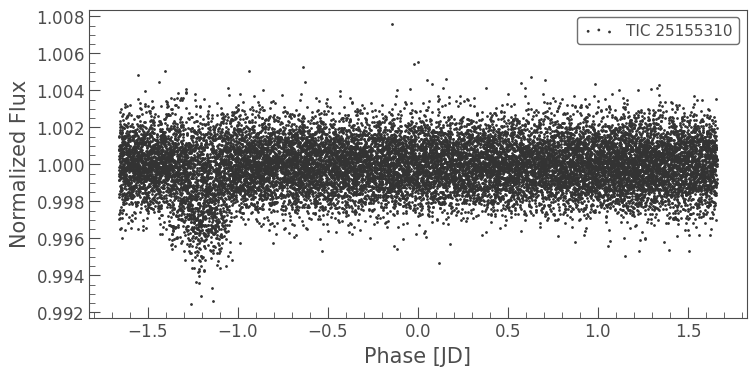

In [26]:
folded_lc=lc_clean.fold(period)
folded_lc.scatter()

In [27]:
mean_flux=folded_lc.flux.mean()
min_flux=folded_lc.flux.min()
print("Mean Flux=",mean_flux)
print("Minimum Flux=",min_flux)

Mean Flux= 0.999919639523394
Minimum Flux= 0.9924738893705322


In [28]:
transit_depth = mean_flux-min_flux
print("Transit Depth=",transit_depth)

Transit Depth= 0.007445750152861863


In [38]:
transit_depth_percent=transit_depth * 100
print("Transit Depth(%)=",transit_depth_percent)

Transit Depth(%)= 0.7445750152861863


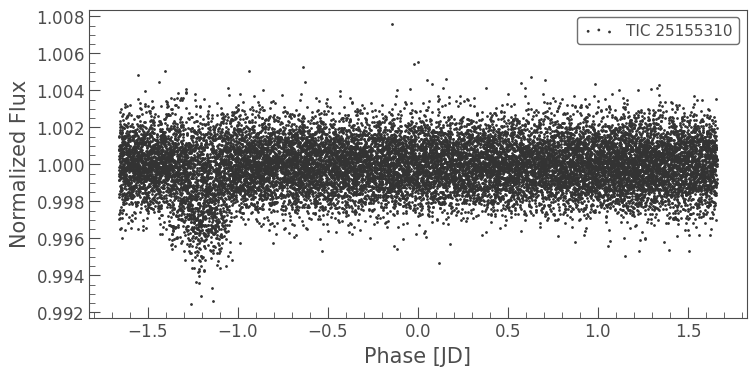

In [39]:
import matplotlib.pyplot as plt
folded_lc.scatter()
plt.show()

In [31]:
import numpy as np
phase=folded_lc.time.value
flux=folded_lc.flux.value
threshold=min_flux+(mean_flux-min_flux)/2
in_transit=flux<threshold
duration_phase=np.max(phase[in_transit])-np.min(phase[in_transit])
transit_duration=duration_phase*period.value
print("Transit Duration (days)=",transit_duration)


Transit Duration (days)= 10.639744017238433


In [32]:
duration_phase=(-1.05)-(-1.35)
transit_duration=duration_phase*period.value
print("Transit Duration(hours)=",transit_duration*24)
print("Transit Duration(days)=",transit_duration)


Transit Duration(hours)= 23.897728806219874
Transit Duration(days)= 0.9957387002591614


In [33]:
print("Orbital Period (days)",period.value)

Orbital Period (days) 3.319129000863871


In [34]:
snr=transit_depth/np.std(flux)
print("SNR=",snr)

SNR= 5.338616460074179


In [35]:
if snr>10:
    print("Confidence Level=High")
elif snr>5:
    print("Confidence Level =Medium")
else:
    print("Confidence Level=Low")


Confidence Level =Medium


In [36]:
print("Classification =Transit Candidate")

Classification =Transit Candidate


In [37]:
print("====FINAL RESULTS=====")
print("Classification=", "Transit Candidate")
print("Orbital Period (days)=", period.value)
print("Transit Depth(%)=", transit_depth*100)
print("Transit Duration(days)=", transit_duration)
print("SNR=", snr)

if snr>10:
    print("Confidence Level=high")
elif snr>5:
    print("Confidence Level=Medium")
else:
    print("Confidence Level=Low")


====FINAL RESULTS=====
Classification= Transit Candidate
Orbital Period (days)= 3.319129000863871
Transit Depth(%)= 0.7445750152861863
Transit Duration(days)= 0.9957387002591614
SNR= 5.338616460074179
Confidence Level=Medium
